In [8]:
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from mlflow.models.signature import infer_signature
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC


In [11]:
df = pd.read_csv('../data/rewiew_restorants_classical.csv')

In [12]:
df

,text,rating,setniment,text_clean
0,Глубинка страны во всех своих проявлениях. Асс...,4.0,0,глубинка страна весь свой проявлениях ассортим...
1,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вку...",5.0,0,<NUMBER> <NUMBER> пить кофе риме париже вкусне...
2,"Не очень удобное расположение, от метро идти м...",4.0,0,очень удобный расположение метро идти мина <NU...
3,"Самый большой плюс это месторасположение, набе...",2.0,1,самый большой плюс это месторасположение набер...
4,Добрый день! Сегодня во второй раз посетили с ...,5.0,0,добрый день сегодня второй посетить дочка рест...
...,...,...,...,...
103087,"Вкуснейшая еда, отличный персонал, ребята моло...",5.0,0,вкусный еда отличный персонал ребята молодцы д...
103088,"Залетели ночью с друзьями, разбудили работника...",1.0,1,залететь ночью друзьями разбудить работника сд...
103089,Очень вкусная пицца. Нравится их система лояль...,5.0,0,очень вкусный пицца нравиться система лояльнос...
103090,"Пицца детям понравилась, интерьер очень интере...",5.0,0,пицца ребёнок понравилась интерьер очень интер...


In [13]:
df_ML = df[['text_clean', 'setniment']]
X, Y = df_ML['text_clean'], df_ML['setniment']
X_train,  X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=True, stratify=Y)

In [14]:
df_ML

,text_clean,setniment
0,глубинка страна весь свой проявлениях ассортим...,0
1,<NUMBER> <NUMBER> пить кофе риме париже вкусне...,0
2,очень удобный расположение метро идти мина <NU...,0
3,самый большой плюс это месторасположение набер...,1
4,добрый день сегодня второй посетить дочка рест...,0
...,...,...
103087,вкусный еда отличный персонал ребята молодцы д...,0
103088,залететь ночью друзьями разбудить работника сд...,1
103089,очень вкусный пицца нравиться система лояльнос...,0
103090,пицца ребёнок понравилась интерьер очень интер...,0


# Naive Bayes

Precision(-): 0.8268, Recall(-): 0.7991, F1(-): 0.8127
ROC-AUC: 0.9716


Registered model 'NB_TFIDF_Model' already exists. Creating a new version of this model...
Created version '2' of model 'NB_TFIDF_Model'.


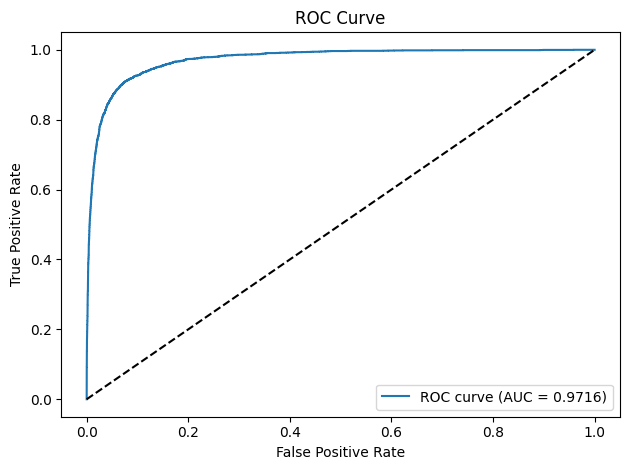

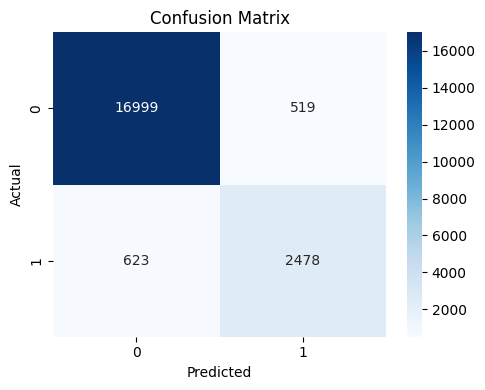

In [15]:
alpha_fixed = 0.1
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ("nb", MultinomialNB(alpha=alpha_fixed))
])

registered_model_name = "NB_TFIDF_Model"
experiment_name = 'ClassicalNLPSentiment'

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name=f"NB_alpha={alpha_fixed}"):

    pipeline.fit(X_train, Y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    y_test_prob = pipeline.predict_proba(X_test)[:,1]


    precision_neg = precision_score(Y_test, y_test_pred, pos_label=1)
    recall_neg    = recall_score(Y_test, y_test_pred, pos_label=1)
    f1_neg        = f1_score(Y_test, y_test_pred, pos_label=1)
    roc_auc      = roc_auc_score(Y_test, y_test_prob)


    mlflow.log_param("alpha", alpha_fixed)


    mlflow.log_metric("precision_negative", precision_neg)
    mlflow.log_metric("recall_negative", recall_neg)
    mlflow.log_metric("f1_negative", f1_neg)
    mlflow.log_metric("roc_auc", roc_auc)

    print(f"Precision(-): {precision_neg:.4f}, Recall(-): {recall_neg:.4f}, F1(-): {f1_neg:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    fpr, tpr, thresholds = roc_curve(Y_test, y_test_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("../artifacts/images/NB_roc_curve.png")
    mlflow.log_artifact("../artifacts/images/NB_roc_curve.png")
    

    cm = confusion_matrix(Y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("../artifacts/images/NB_confusion_matrix.png")
    mlflow.log_artifact("../artifacts/images/NB_confusion_matrix.png")

    example_input = X_train[:5].to_frame()
    signature = infer_signature(X_train, pipeline.predict(X_train[:5]))
    
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        name="nb_pipeline",
        signature=signature,
        input_example=example_input,
        registered_model_name=registered_model_name,
        metadata={"dataset_name": "classicalCleanTextOverview.csv"}
    )

    dataset_path = "../artifacts/datasets/classicalCleanTextOverview.csv"
    df_ML.to_csv(dataset_path, index=False)
    mlflow.log_artifact(dataset_path, artifact_path='dataset')

ВЫВОДЫ:
Наивный Байесовский классификатор показал себя очень хорошо:
- Precision: 0.8268 
- Recall: 0.7991 
- F1: 0.8127
- ROC-AUC: 0.9716

# SVM

Precision(-): 0.8548, Recall(-): 0.7743, F1(-): 0.8125
ROC-AUC: 0.9722


Registered model 'SVM_TFIDF_Model' already exists. Creating a new version of this model...
Created version '2' of model 'SVM_TFIDF_Model'.


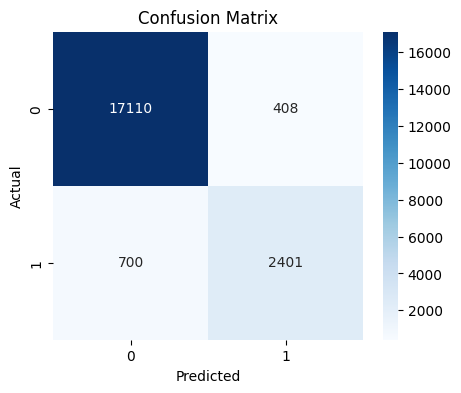

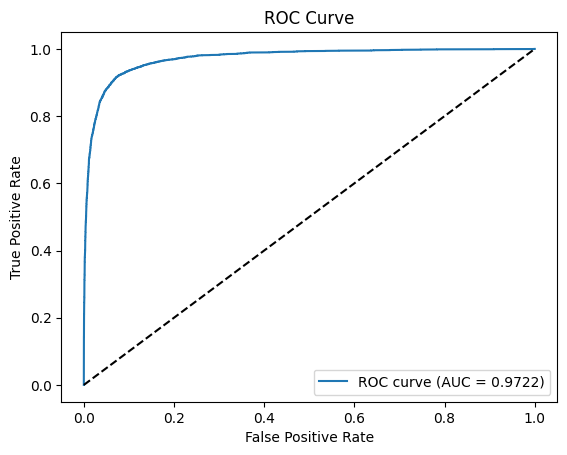

In [17]:
mlflow.set_experiment(experiment_name)
registered_model_name = "SVM_TFIDF_Model"

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ("svm", CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000)))
])

with mlflow.start_run(run_name="SVM_TFIDF"):

    pipeline.fit(X_train, Y_train)

   
    y_test_pred = pipeline.predict(X_test)
    y_test_prob = pipeline.predict_proba(X_test)[:,1]

    precision_neg = precision_score(Y_test, y_test_pred, pos_label=1)
    recall_neg    = recall_score(Y_test, y_test_pred, pos_label=1)
    f1_neg        = f1_score(Y_test, y_test_pred, pos_label=1)
    roc_auc       = roc_auc_score(Y_test, y_test_prob)

    mlflow.log_metric("precision_negative", precision_neg)
    mlflow.log_metric("recall_negative", recall_neg)
    mlflow.log_metric("f1_negative", f1_neg)
    mlflow.log_metric("roc_auc", roc_auc)

    cm = confusion_matrix(Y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    cm_path = "../artifacts/images/SVM_cm.png"
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)


    fpr, tpr, thresholds = roc_curve(Y_test, y_test_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    roc_path = "../artifacts/images/SVM_roc_curve.png"
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path)

    example_input = X_train[:5].to_frame()  
    signature = infer_signature(example_input, pipeline.predict(example_input))
    
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        name="svm_pipeline",
        signature=signature,
        input_example=example_input,
        registered_model_name=registered_model_name
    )

    mlflow.log_artifact(dataset_path, artifact_path="dataset")
    print(f"Precision(-): {precision_neg:.4f}, Recall(-): {recall_neg:.4f}, F1(-): {f1_neg:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    

SVM показал схожие результаты:
- Precision: 0.8548
- Recall(-): 0.7743
- F1(-): 0.8125
- ROC-AUC: 0.9722

Но у него выше Precision при чуть меньшем recall